In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
import arviz as az
import lightkurve as lk
from gp_model_new import harmonic_sho_model
import matplotlib.pyplot as plt
import numpy as np
import emcee
from celerite2 import terms
from celerite2 import GaussianProcess
from scipy.stats import norm, halfnorm, lognorm, uniform
import scipy.stats as ss
import seaborn as sns
from tqdm import tqdm
import pandas as pd
import os
import glob
from astropy.io import fits
from astropy.stats import sigma_clip
import ipywidgets

sns.set_theme(context='notebook', style='ticks', palette='colorblind')

/Users/sabina/miniconda3/envs/jax-env/lib/python3.12/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/sabina/.lightkurve/cache. Please move all the files in the legacy directory /Users/sabina/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


In [3]:
import astropy
ipywidgets.__version__

'8.1.5'

In [4]:
def get_detrended_lc(kepler_id, data_dir):

    search_pattern = os.path.join(data_dir, f"KIC_{kepler_id}", "*.fits")
    fits_files = sorted(glob.glob(search_pattern))

    print(f"Found {len(fits_files)} FITS files for KIC {kepler_id}")

    times_list = []
    fluxes_list = []
    flux_errs_list = []
    quarters_list = []

    for i, fits_file in enumerate(fits_files):
        filename = os.path.basename(fits_file)
        if "q" in filename and filename.split("q")[1][:2].isdigit():
            quarter = int(filename.split("q")[1][:2])
        else:
            quarter = i
        
        with fits.open(fits_file) as hdul:
            data = hdul[1].data
            
            time_data = np.array(data['TIME'], dtype=np.float64)
            flux_data = np.array(data['FLUX_DETREND'], dtype=np.float64)
            flux_err_data = np.array(data['FLUX_DETREND_ERR_EST'], dtype=np.float64)
            
            if time_data.ndim > 1:
                time_data = time_data.flatten()
            if flux_data.ndim > 1:
                flux_data = flux_data.flatten()
            if flux_err_data.ndim > 1:
                flux_err_data = flux_err_data.flatten()
            
            mask = ~np.isnan(flux_data)
            
            valid_time = time_data[mask]
            valid_flux = flux_data[mask]
            valid_flux_err = flux_err_data[mask]
            
            if len(valid_flux) > 0:
                flux_mean = np.mean(valid_flux)
                valid_flux = valid_flux / flux_mean
                valid_flux_err = valid_flux_err / flux_mean  
                
                times_list.append(valid_time)
                fluxes_list.append(valid_flux)
                flux_errs_list.append(valid_flux_err)
                quarters_list.append(np.ones_like(valid_time) * quarter)
            
                print(f"Added {np.sum(mask)} points from quarter {quarter}")


    # After loading all the data and before any plotting or analysis
    if times_list:
        times = np.concatenate(times_list)
        fluxes = np.concatenate(fluxes_list)
        flux_errs = np.concatenate(flux_errs_list)
        quarters = np.concatenate(quarters_list)
    
        uquarters, quarter_indices = np.unique(quarters, return_inverse=True)
        
        # Apply sigma clipping by quarter to handle different flux levels
        clipped_indices = []
        for quarter in uquarters:
            q_mask = quarters == quarter
            q_fluxes = fluxes[q_mask]
            
            # Identify outliers using sigma_clip
            # Adjust sigma and maxiters as needed
            filtered_data = sigma_clip(q_fluxes, sigma=5, maxiters=5)
            quarter_outliers = np.where(q_mask)[0][filtered_data.mask]
            clipped_indices.extend(quarter_outliers)
        
        # Create mask for all valid data points (not outliers)
        valid_mask = np.ones(len(fluxes), dtype=bool)
        valid_mask[clipped_indices] = False
        
        # Apply the mask to all data
        times = times[valid_mask]
        fluxes = fluxes[valid_mask]
        flux_errs = flux_errs[valid_mask]
        quarters = quarters[valid_mask]
        
        # Update quarter indices after clipping
        uquarters, quarter_indices = np.unique(quarters, return_inverse=True)
        
        print(f"Removed {len(clipped_indices)} outlier points using sigma clipping")
    else:
        print("No valid data found")
    
    return times, fluxes, flux_errs, quarters, quarter_indices

In [5]:
kepler_id = 5023760
data_dir = "kepler_detrended"  

times, fluxes, flux_errs, quarters, quarter_indices = get_detrended_lc(kepler_id,data_dir)

Found 5 FITS files for KIC 5023760
Added 4076 points from quarter 2
Added 4142 points from quarter 3
Added 4229 points from quarter 7
Added 4520 points from quarter 11
Added 4386 points from quarter 15
Removed 12 outlier points using sigma clipping


Text(0.5, 1.0, '5023760')

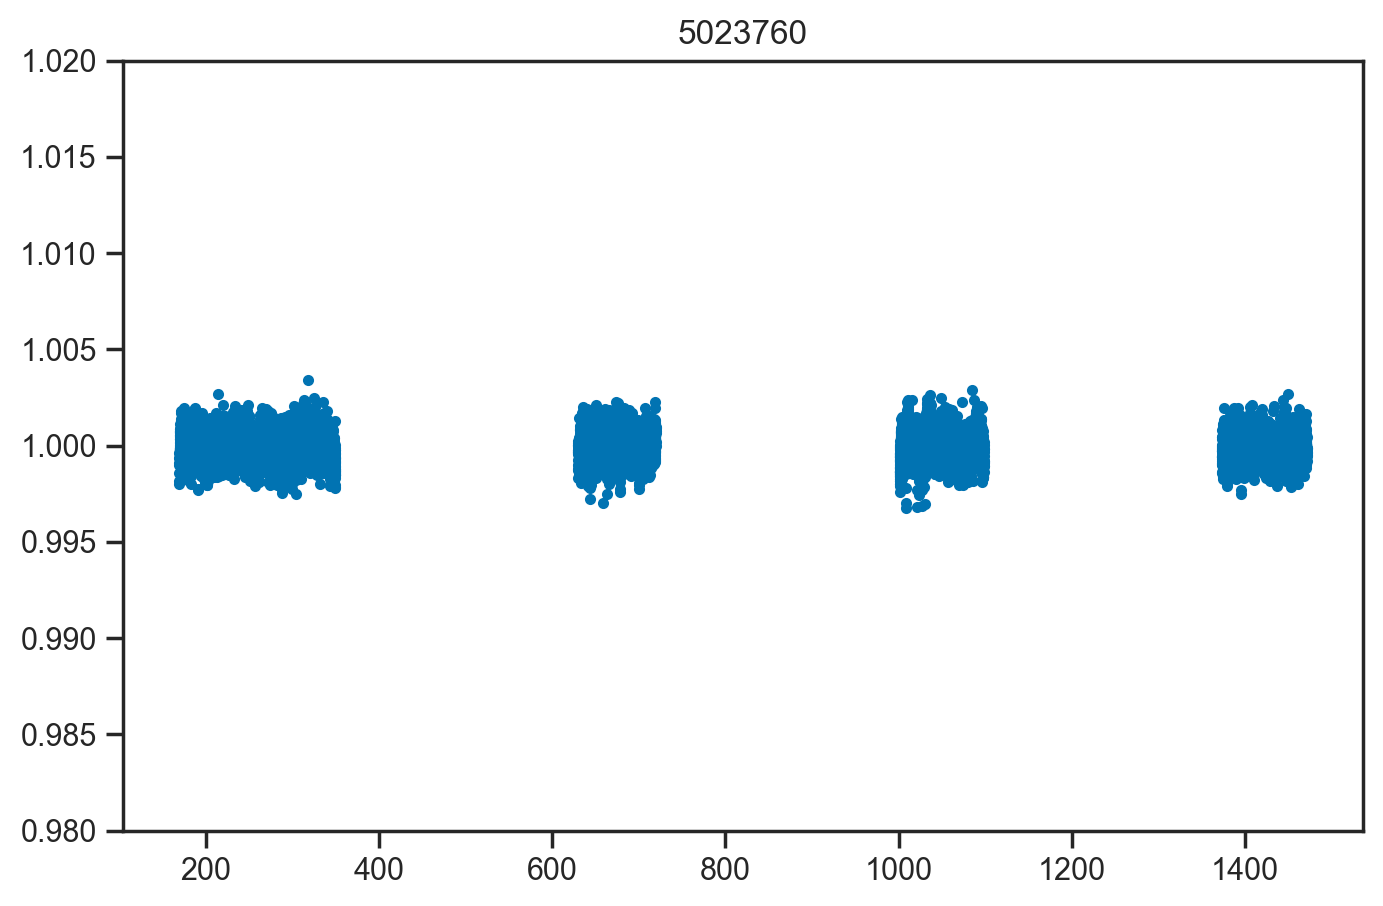

In [6]:
plt.figure(figsize=(8,5))
plt.plot(times, fluxes, '.')
# plt.xlim(300,420)
plt.ylim(0.98,1.02)
plt.title(kepler_id)

In [7]:
f_best_literature = 1/4.78

Now let's try fitting some GP models.

In [8]:
def get_best_chain(trace):
    """Extract the chain with the highest mean log probability."""
    # Get mean log probability for each chain
    chain_lp = trace.sample_stats.lp.mean(dim='draw').values
    best_chain_idx = np.argmax(chain_lp)
    
    return best_chain_idx, chain_lp[best_chain_idx]

In [9]:
def bin_data(times, fluxes, flux_errs, bin_width):
    """Bin the time series data with specified bin width."""
    # Find min and max times
    t_min, t_max = np.min(times), np.max(times)
    # Create bin edges
    bins = np.arange(t_min, t_max + bin_width, bin_width)
    # Find bin indices for each time point
    indices = np.digitize(times, bins)
    
    # Initialize arrays for binned data
    binned_times = []
    binned_fluxes = []
    binned_flux_errs = []
    
    # Loop through each bin (excluding the last edge)
    for i in range(1, len(bins)):
        # Get points in this bin
        bin_mask = indices == i
        bin_count = np.sum(bin_mask)
        
        if bin_count > 0:
            # Calculate mean time, flux and flux_err for this bin
            bin_time = np.mean(times[bin_mask])
            bin_flux = np.mean(fluxes[bin_mask])
            
            # Calculate error as either the standard error of the mean or
            # the propagated measurement error, whichever is larger
            std_err = np.std(fluxes[bin_mask]) / np.sqrt(bin_count)
            mean_err = np.mean(flux_errs[bin_mask]) / np.sqrt(bin_count)
            bin_flux_err = max(std_err, mean_err)
            
            binned_times.append(bin_time)
            binned_fluxes.append(bin_flux)
            binned_flux_errs.append(bin_flux_err)
    
    return np.array(binned_times), np.array(binned_fluxes), np.array(binned_flux_errs)

In [10]:
period_ls = 20

In [11]:
times_, fluxes_, sigmas_ = bin_data(times, fluxes, flux_errs, period_ls/50)

In [12]:
# Prepare for GP model - keep quarter information for binned data
binned_quarters = np.zeros_like(times_, dtype=int)
for i, t in enumerate(times_):
    # Assign the quarter that contains the most points near this binned time
    time_diffs = np.abs(times - t)
    closest_indices = np.argsort(time_diffs)[:10]  # Get 10 closest points
    most_common_quarter = np.bincount(quarters[closest_indices].astype(int)).argmax()
    binned_quarters[i] = most_common_quarter

In [13]:
f0_1_2 = 1/(1 * np.sqrt(2))   
f0_2_4 = 1/(2 * np.sqrt(2))   
f0_4_8 = 1/(4 * np.sqrt(2))    
f0_8_16 = 1/(8 * np.sqrt(2))   
f0_16_32 = 1/(16 * np.sqrt(2)) 

In [14]:
# Prepare frequency grid for PSD - create a better range centered around f_best
fprior = f0_4_8.copy()
f_min = min(fprior/4, 0.01)  # Go down to 1/4 of best frequency or 0.01, whichever is smaller
f_max = fprior*4  # Go up to 4x the best frequency
n_freqs = 1000  # Number of frequency points

# Create a logarithmically spaced frequency grid for better resolution at lower frequencies
frequencies = np.logspace(np.log10(f_min), np.log10(f_max), n_freqs)

In [15]:
uquarters, quarter_indices = np.unique(binned_quarters, return_inverse=True)
nquarters = len(uquarters)

n_in_quarters = np.bincount(quarter_indices)
mu_quarters = np.bincount(quarter_indices, weights=fluxes_) / n_in_quarters
var_quarters = np.bincount(quarter_indices, weights=np.square(fluxes_ - mu_quarters[quarter_indices])) / n_in_quarters
std_quarters = np.sqrt(var_quarters)
rel_std_quarters = std_quarters / mu_quarters

In [16]:
T_obs = np.max(t) - np.min(t)
longest_period = 1.0 / (fprior / np.sqrt(2))

In [17]:
model = harmonic_sho_model(times_, fluxes_, sigmas_, binned_quarters, fprior, psd_freq=frequencies, predict_flux=True)

In [18]:
with model:
    logp_fn = model.compile_logp()  # NOT model.logp_dlogp_function()
    ip = model.initial_point()
    param_names = list(ip.keys())

In [19]:
initial_params = []
for name in param_names:
    val = ip[name]
    if np.isscalar(val):
        initial_params.append(val)
    else:
        initial_params.extend(val.flatten())
initial_params = np.array(initial_params)
ndim = len(initial_params)

nwalkers = 2 * ndim

In [20]:
param_names

['log_scale_factors_scaled',
 'log_period_interval__',
 'sigma_scaled_log__',
 'frac_interval__',
 'dQ1_log__',
 'dQb_log__',
 'log_timescale_interval__',
 'sigma_red_noise_scaled_log__']

In [21]:
def log_prob_wrapper(theta):
    """Wrapper for emcee that handles PyMC's log probability."""
    # Convert flattened theta back to PyMC parameter dictionary
    param_dict = {}
    idx = 0
    for name in param_names:
        original_val = ip[name]
        if np.isscalar(original_val):
            param_dict[name] = theta[idx]
            idx += 1
        else:
            size = int(np.prod(original_val.shape))
            param_dict[name] = theta[idx:idx+size].reshape(original_val.shape)
            idx += size
    logp = logp_fn(param_dict)  # No unpacking, just get logp
    try:
        return logp if not np.isnan(logp) else -np.inf
    except:
        return -np.inf

In [22]:
pos = initial_params + 1e-4 * np.random.randn(nwalkers, ndim)

In [23]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob_wrapper)

In [24]:
nsteps = 6000
sampler.run_mcmc(pos, nsteps, progress=True)

100%|██████████| 6000/6000 [00:57<00:00, 104.52it/s]


State([[-5.03940733e+00  2.94684094e+00  3.12150649e+00  1.55334898e+00
   1.18180265e+00 -2.68998600e+00 -5.27818893e-01 -2.16909947e+00
   1.34410234e-01 -1.69197692e+00 -1.04863895e+00 -9.90990917e-02]
 [-2.41253820e+00 -3.54793678e+00 -1.30195935e-01 -9.88035804e-01
  -2.33289055e+00 -1.80780555e+00 -4.83915710e-01 -2.58702944e+00
  -1.71656898e-01 -4.78458926e-01 -1.14409530e+00 -1.46797901e-01]
 [ 1.04327250e+00  3.65213760e+00 -5.88165725e+00 -3.43325029e+00
   1.47093356e+00 -1.05437841e+00 -6.61781215e-01 -2.01048024e+00
  -3.42220433e-01  1.30367241e-01 -8.74786317e-01  1.32481745e-01]
 [-4.10649990e+00 -1.85307851e+00  4.43268824e-01  1.59245449e+00
   6.90587642e+00 -2.25853524e+00 -4.65231991e-01 -2.15264043e+00
  -3.67472723e-01  1.80962266e-01 -1.10921656e+00 -2.06477071e-01]
 [ 3.65603711e+00 -4.07804030e+00  6.57947284e+00 -4.26327972e+00
  -4.28084470e-01 -1.93780731e+00 -6.81443298e-01 -1.84277843e+00
  -2.78463540e-01 -1.47656857e-01 -1.00565798e+00 -1.30485056e-01]

In [41]:
def transform_to_original_params(samples, param_names, t, y, yerr, yquarters, f0):
   
   uquarters, quarter_indices = np.unique(yquarters, return_inverse=True)
   n_in_quarters = np.bincount(quarter_indices)
   mu_quarters = np.bincount(quarter_indices, weights=y) / n_in_quarters
   var_quarters = np.bincount(quarter_indices, weights=np.square(y - mu_quarters[quarter_indices])) / n_in_quarters
   std_quarters = np.sqrt(var_quarters)
   rel_std_quarters = std_quarters / mu_quarters
   nquarters = len(uquarters)
   
   # Get samples shape: (nsteps, nwalkers, ndim)
   nsteps, nwalkers, ndim = samples.shape
   print(f"Transforming samples shape: {samples.shape}")
   print(f"Parameter names: {param_names}")
   
   results = {}
   
   # Initialize results with shape (nwalkers, nsteps)
   results['period'] = np.zeros((nwalkers, nsteps))
   results['f0'] = np.zeros((nwalkers, nsteps))
   results['sigma'] = np.zeros((nwalkers, nsteps))
   results['frac'] = np.zeros((nwalkers, nsteps))
   results['dQ1'] = np.zeros((nwalkers, nsteps))
   results['dQb'] = np.zeros((nwalkers, nsteps))
   results['Q0'] = np.zeros((nwalkers, nsteps))
   results['Q1'] = np.zeros((nwalkers, nsteps))
   results['timescale'] = np.zeros((nwalkers, nsteps))
   results['c'] = np.zeros((nwalkers, nsteps))
   results['sigma_red_noise'] = np.zeros((nwalkers, nsteps))
   results['scale_factors'] = np.zeros((nwalkers, nsteps, nquarters))
   results['mus'] = np.zeros((nwalkers, nsteps, nquarters))
   results['log_period'] = np.zeros((nwalkers, nsteps))
   results['sigma_scaled'] = np.zeros((nwalkers, nsteps))
   results['log_scale_factors_scaled'] = np.zeros((nwalkers, nsteps, nquarters))
   
   for step in range(nsteps):
       for walker in range(nwalkers):
           sample = samples[step, walker, :]
           
           idx = 0
           
           log_scale_factors_scaled = sample[idx:idx+nquarters]
           idx += nquarters
           
           log_period_transformed = sample[idx]; idx += 1  # 'log_period_interval__'
           sigma_scaled_log_transformed = sample[idx]; idx += 1  # 'sigma_scaled_log__'
           frac_transformed = sample[idx]; idx += 1  # 'frac_interval__'
           dQ1_log_transformed = sample[idx]; idx += 1  # 'dQ1_log__'
           dQb_log_transformed = sample[idx]; idx += 1  # 'dQb_log__'
           log_timescale_transformed = sample[idx]; idx += 1  # 'log_timescale_interval__'
           sigma_red_noise_scaled_log_transformed = sample[idx]; idx += 1  # 'sigma_red_noise_scaled_log__'
           
           # Transform back to original space
           # PyMC's interval transforms use logit, log transforms use exp
           
           # log_period_interval__ -> log_period (this was uniform, so logit transform)
           # logit^-1(x) = exp(x) / (1 + exp(x)), then scale to [low, high]
           log_f0 = np.log(f0)
           low_log_period = -log_f0 - np.log(np.sqrt(2))
           high_log_period = -log_f0 + np.log(np.sqrt(2))
           log_period_prob = np.exp(log_period_transformed) / (1 + np.exp(log_period_transformed))
           log_period = low_log_period + (high_log_period - low_log_period) * log_period_prob
           
           # frac_interval__ -> frac (uniform [0,1], so logit transform)
           frac = np.exp(frac_transformed) / (1 + np.exp(frac_transformed))
           
           # log_timescale_interval__ -> log_timescale (uniform, so logit transform)
           longest_period = 1.0 / (f0 / np.sqrt(2))
           T_obs = np.max(t) - np.min(t)
           low_log_timescale = np.log(longest_period)
           high_log_timescale = np.log(T_obs)
           log_timescale_prob = np.exp(log_timescale_transformed) / (1 + np.exp(log_timescale_transformed))
           log_timescale = low_log_timescale + (high_log_timescale - low_log_timescale) * log_timescale_prob
           
           # sigma_scaled_log__ -> sigma_scaled (HalfNormal, so log transform)
           sigma_scaled = np.exp(sigma_scaled_log_transformed)
           
           # dQ1_log__ -> dQ1 (LogNormal, so already in log space)
           dQ1 = np.exp(dQ1_log_transformed)
           
           # dQb_log__ -> dQb (LogNormal, so already in log space) 
           dQb = np.exp(dQb_log_transformed)
           
           # sigma_red_noise_scaled_log__ -> sigma_red_noise_scaled (HalfNormal, so log transform)
           sigma_red_noise_scaled = np.exp(sigma_red_noise_scaled_log_transformed)
           
           log_scale_factors = (rel_std_quarters / np.sqrt(n_in_quarters)) * log_scale_factors_scaled
           scale_factors = np.exp(log_scale_factors)
           mus = mu_quarters * scale_factors
           
           period = np.exp(log_period)
           f0_sample = 1.0 / period
           
           sigma = sigma_scaled * np.median(rel_std_quarters)
           
           Q0 = 0.5 + dQ1 + dQb  # Note: using dQb, not dQ0
           Q1 = 0.5 + dQ1
           
           timescale = np.exp(log_timescale)
           c = 2*np.pi*1.0/timescale
           
           sigma_red_noise = sigma_red_noise_scaled * np.median(rel_std_quarters)
           
           results['period'][walker, step] = period
           results['f0'][walker, step] = f0_sample
           results['sigma'][walker, step] = sigma
           results['frac'][walker, step] = frac
           results['dQ1'][walker, step] = dQ1
           results['dQb'][walker, step] = dQb
           results['Q0'][walker, step] = Q0
           results['Q1'][walker, step] = Q1
           results['timescale'][walker, step] = timescale
           results['c'][walker, step] = c
           results['sigma_red_noise'][walker, step] = sigma_red_noise
           results['scale_factors'][walker, step] = scale_factors
           results['mus'][walker, step] = mus
           
           results['log_period'][walker, step] = log_period
           results['sigma_scaled'][walker, step] = sigma_scaled
           results['log_scale_factors_scaled'][walker, step] = log_scale_factors_scaled
   
   return results

In [42]:
samples_unconstrained = sampler.get_chain(discard=1000)
results = transform_to_original_params(samples_unconstrained, param_names, times_, fluxes_, sigmas_, binned_quarters, fprior)

Transforming samples shape: (5000, 24, 12)
Parameter names: ['log_scale_factors_scaled', 'log_period_interval__', 'sigma_scaled_log__', 'frac_interval__', 'dQ1_log__', 'dQb_log__', 'log_timescale_interval__', 'sigma_red_noise_scaled_log__']


In [43]:
results['period'].shape

(24, 5000)

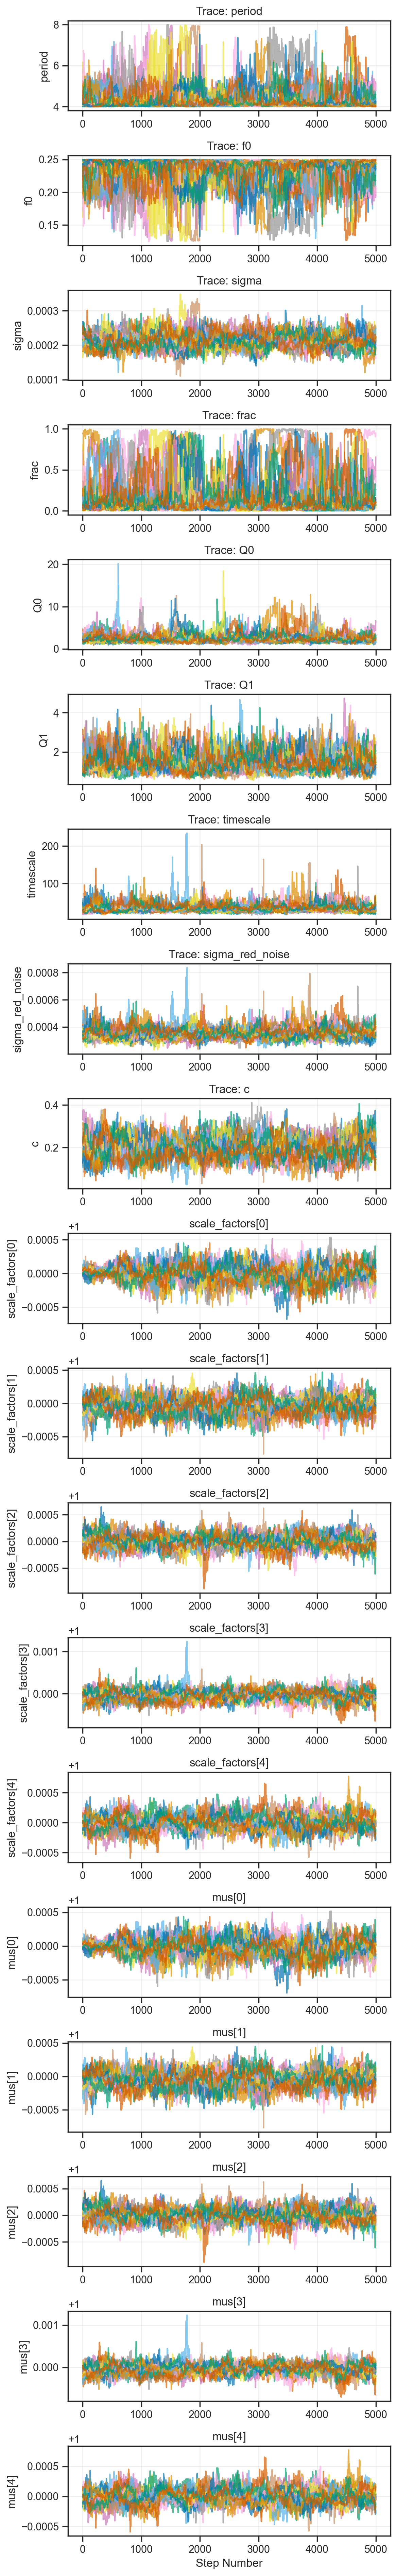

In [44]:
params_to_plot = [
       'period', 'f0', 'sigma', 'frac', 'Q0', 'Q1', 
       'timescale', 'sigma_red_noise', 'c'
]
   
array_params = ['scale_factors', 'mus']
total_plots = len(params_to_plot)
for param in array_params:
   if param in results:
       total_plots += results[param].shape[2]  # shape is (nwalkers, nsteps, nquarters)

fig, axes = plt.subplots(total_plots, 1, figsize=(6, 2 * total_plots))
if total_plots == 1:
   axes = [axes]

plot_idx = 0

for param in params_to_plot:
   if param in results:
       data = results[param][:,:]  # shape: (nwalkers, nsteps_after_burnin)

       for walker in range(data.shape[0]):
           axes[plot_idx].plot(data[walker, :], alpha=0.7)
       axes[plot_idx].set_ylabel(param)
       axes[plot_idx].set_title(f'Trace: {param}')
       axes[plot_idx].grid(True, alpha=0.3)
       plot_idx += 1

for param in array_params:
   if param in results:
       data = results[param][:, :, :]  # shape: (nwalkers, nsteps_after_burnin, nquarters)
       for i in range(data.shape[2]):  # For each quarter
           for walker in range(data.shape[0]):
               axes[plot_idx].plot(data[walker, :, i], alpha=0.7)
           axes[plot_idx].set_ylabel(f'{param}[{i}]')
           axes[plot_idx].set_title(f'{param}[{i}]')
           axes[plot_idx].grid(True, alpha=0.3)
           plot_idx += 1
   
axes[-1].set_xlabel('Step Number')
plt.tight_layout()
plt.show()

In [45]:
scalar_params = ['period', 'f0', 'sigma', 'frac', 'dQ1', 'dQb', 'Q0', 'Q1', 
                    'timescale', 'sigma_red_noise', 'c']

for param in scalar_params:
    if param in results:
        data = results[param]
        mean_val = np.mean(data)
        std_val = np.std(data)
        q025 = np.percentile(data, 2.5)
        q975 = np.percentile(data, 97.5)
        print(f"{param:15s}: {mean_val:8.4f} ± {std_val:7.4f}  [{q025:8.4f}, {q975:8.4f}]")

# Array parameters
array_params = ['scale_factors', 'mus']
for param in array_params:
    if param in results:
        data = results[param]
        for i in range(data.shape[1]):
            param_data = data[:, i]
            mean_val = np.mean(param_data)
            std_val = np.std(param_data)
            q025 = np.percentile(param_data, 2.5)
            q975 = np.percentile(param_data, 97.5)
            print(f"{param}[{i}]:10s: {mean_val:8.4f} ± {std_val:7.4f}  [{q025:8.4f}, {q975:8.4f}]")


period         :   4.3822 ±  0.5013  [  4.0056,   5.7461]
f0             :   0.2305 ±  0.0206  [  0.1740,   0.2497]
sigma          :   0.0002 ±  0.0000  [  0.0002,   0.0003]
frac           :   0.1747 ±  0.2142  [  0.0043,   0.8788]
dQ1            :   1.0212 ±  0.4704  [  0.3082,   2.0914]
dQb            :   0.9397 ±  0.7644  [  0.2101,   2.8746]
Q0             :   2.4609 ±  0.9686  [  1.3383,   4.9426]
Q1             :   1.5212 ±  0.4704  [  0.8082,   2.5914]
timescale      :  33.8306 ±  9.4231  [ 21.5862,  56.4214]
sigma_red_noise:   0.0004 ±  0.0000  [  0.0003,   0.0004]
c              :   0.1972 ±  0.0454  [  0.1114,   0.2911]
scale_factors[0]:10s:   1.0000 ±  0.0001  [  0.9998,   1.0002]
scale_factors[1]:10s:   1.0000 ±  0.0001  [  0.9998,   1.0002]
scale_factors[2]:10s:   1.0000 ±  0.0001  [  0.9998,   1.0002]
scale_factors[3]:10s:   1.0000 ±  0.0001  [  0.9998,   1.0002]
scale_factors[4]:10s:   1.0000 ±  0.0001  [  0.9997,   1.0002]
scale_factors[5]:10s:   1.0000 ±  0.0001  [  0.

In [30]:
results['period'].shape[1]

5000

Text(0.5, 1.0, '$P = {4.209}^{+0.507}_{-0.157} \\, \\mathrm{d}$')

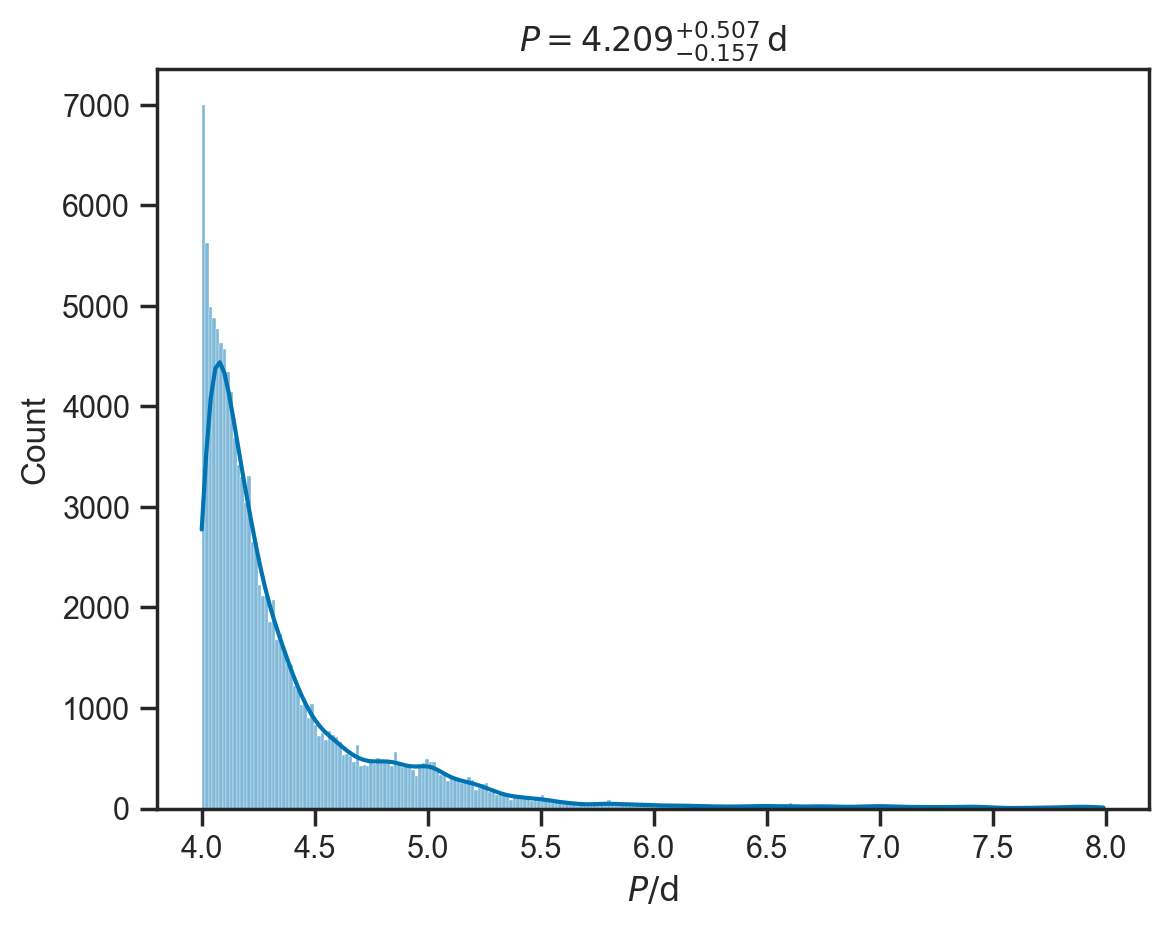

In [46]:
import seaborn as sns
Ps = results['period'].flatten()
m, l, h = np.quantile(Ps, [0.5, 0.16, 0.84])

sns.histplot(Ps, kde=True)
plt.xlabel(r'$P / \mathrm{d}$')
plt.title(r'$P = {{{:.3f}}}^{{+{:.3f}}}_{{-{:.3f}}} \, \mathrm{{d}}$'.format(m, h-m, m-l))

/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_44019/225043915.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


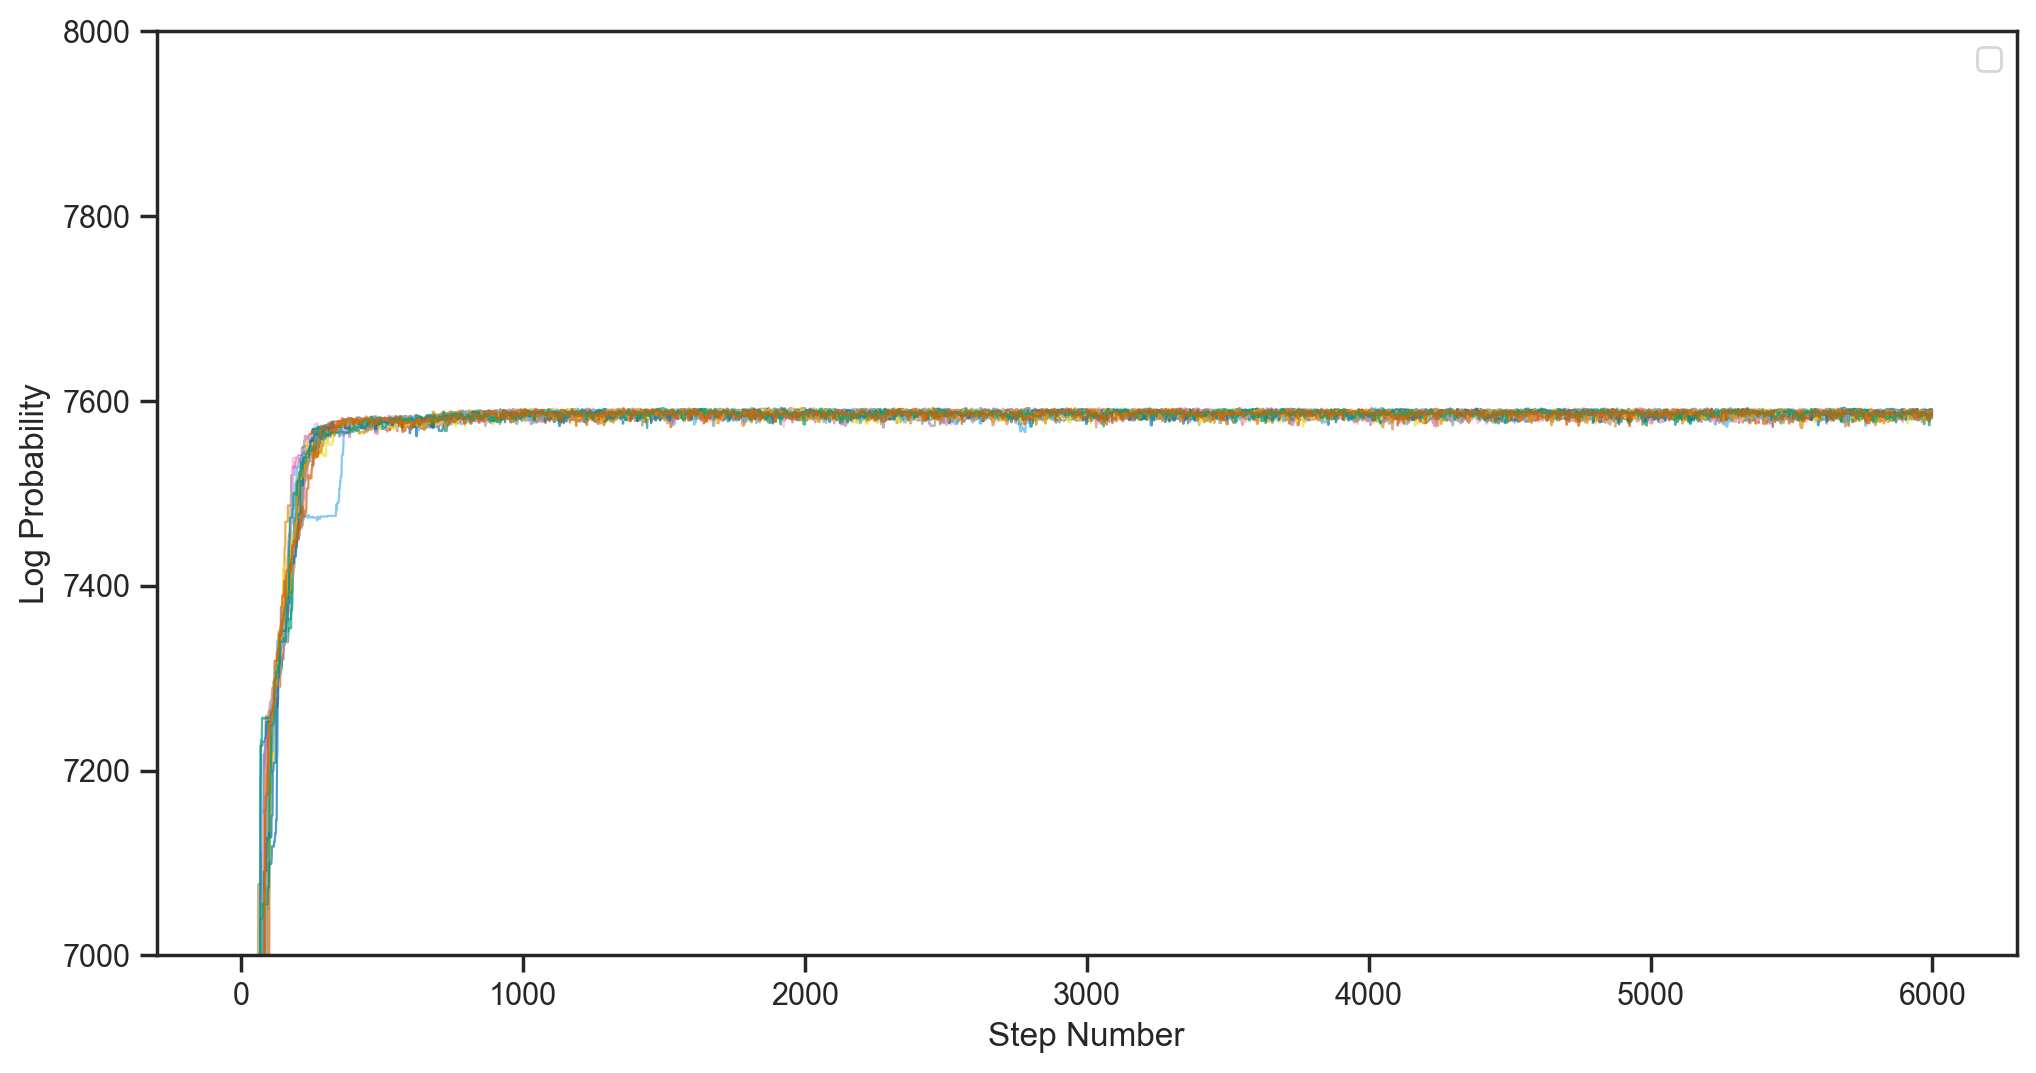

In [32]:
nwalkers, nsteps = results['period'].shape

log_probs = sampler.get_log_prob(discard=0) 
log_probs = log_probs.T  

plt.figure(figsize=(12, 6))

for walker in range(nwalkers):
   plt.plot(log_probs[walker, :], alpha=0.7, linewidth=0.8)

plt.xlabel('Step Number')
plt.ylabel('Log Probability')
plt.legend()
plt.ylim(7000,8000)
plt.show()

In [33]:
logp_4_8 = log_probs.flatten().mean()

In [34]:
logp_4_8

7527.288584137983

In [38]:
nsteps = 2000
sampler.run_mcmc(samples_unconstrained[-1], nsteps, progress=True)

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:17<00:00, 111.65it/s]


State([[ 6.62899439e+00 -1.90563790e+00  1.58090161e+00  2.22756155e+00
   1.07955409e+00 -3.87870197e+00 -7.21071498e-01 -3.34595648e+00
  -1.95505169e-02 -6.17528256e-01 -1.91420306e+00  2.58653445e-03]
 [ 4.84389568e+00  2.42313246e+00 -1.70753509e+00 -3.22641657e+00
  -4.24680920e+00 -1.10486272e-01 -4.47300750e-01  4.68266310e-01
  -2.73711011e-01 -1.71261908e+00 -7.96084747e-01  2.14169979e-02]
 [ 2.14045964e+00 -5.18649630e+00 -2.96171039e+00  4.56964963e+00
  -2.30542733e-01 -2.47021254e+00 -6.54690139e-01 -2.03260002e+00
  -3.09127802e-01 -4.15292451e-04 -1.76458636e+00 -9.13637166e-02]
 [-3.79988097e+00  4.76706539e-01  2.30269426e+00 -7.99199585e-01
   3.75757012e+00 -1.81184436e+00 -5.91567269e-01 -1.63558720e+00
   2.64902070e-01  1.20030158e-01 -2.18626041e+00 -1.17314008e-01]
 [ 3.15220736e-01 -2.82171883e+00 -5.43588370e-01 -5.24690279e-01
  -9.83377587e+00 -1.98094626e+00 -7.00645195e-01 -7.09411064e-01
   4.08807360e-01 -1.34921153e+00 -2.05547116e+00 -1.36866131e-01]

In [35]:
n_total = len(results['period'])  
n_samples = 10
selected_indices = np.random.choice(n_total, size=n_samples, replace=False)
    
lightcurve_samples = []
    
for i in range(n_samples):
    walker_idx = np.random.randint(0, nwalkers)
    step_idx = np.random.randint(0, nsteps)
    
    param_dict = {}
    for name, values in results.items():
        # idk why these are not in the graph...
        if name=='f0' or name=='Q0' or name=='Q1' or name=='mus' or name=='log_period' or name=='sigma_scaled' or name=='log_scale_factors_scaled': continue
        
        if values.ndim == 2:  # (nwalkers, nsteps)
            param_dict[name] = values[walker_idx, step_idx]  
        elif values.ndim == 3:  # (nwalkers, nsteps, nquarters)
            param_dict[name] = values[walker_idx, step_idx, :] 
    
    lightcurve = model.gp_mean_model.eval(param_dict)
    lightcurve_samples.append(lightcurve)

lightcurve_samples = np.array(lightcurve_samples)

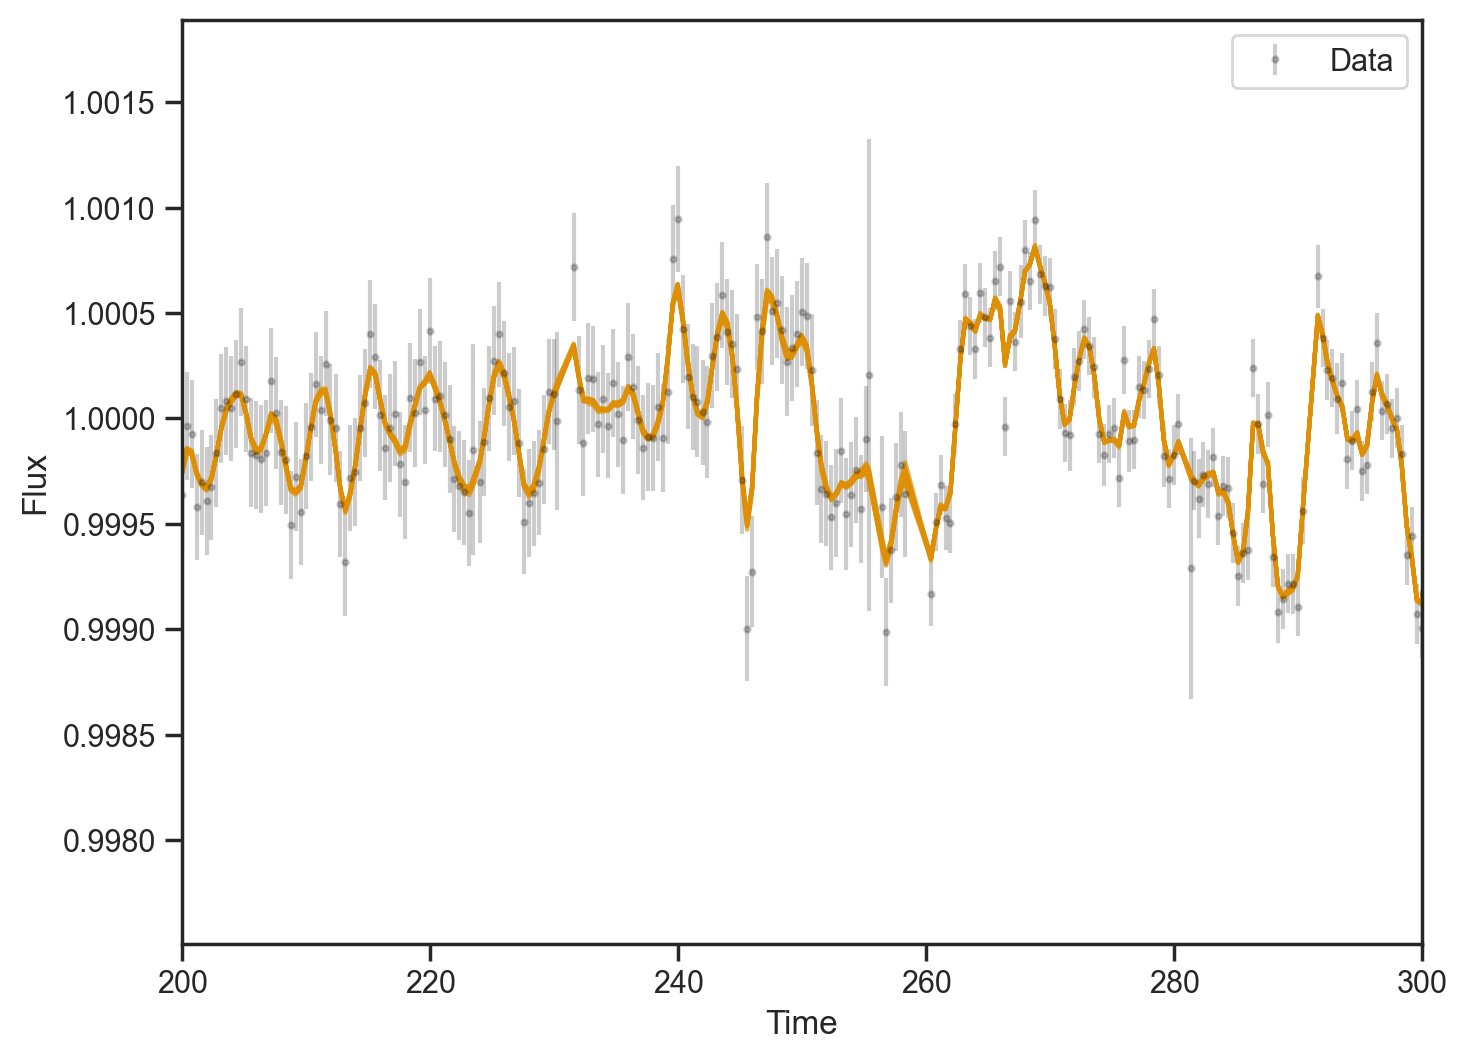

In [36]:
plt.figure(figsize=(8, 6))

plt.errorbar(times_, fluxes_, yerr=sigmas_, fmt='o', alpha=0.2, markersize=2, 
                color='black', label='Data')

for i in range(n_samples):
    plt.plot(times_, lightcurve_samples[i], '-',alpha=0.7, color='C1')

plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.xlim(200,300)
plt.show()

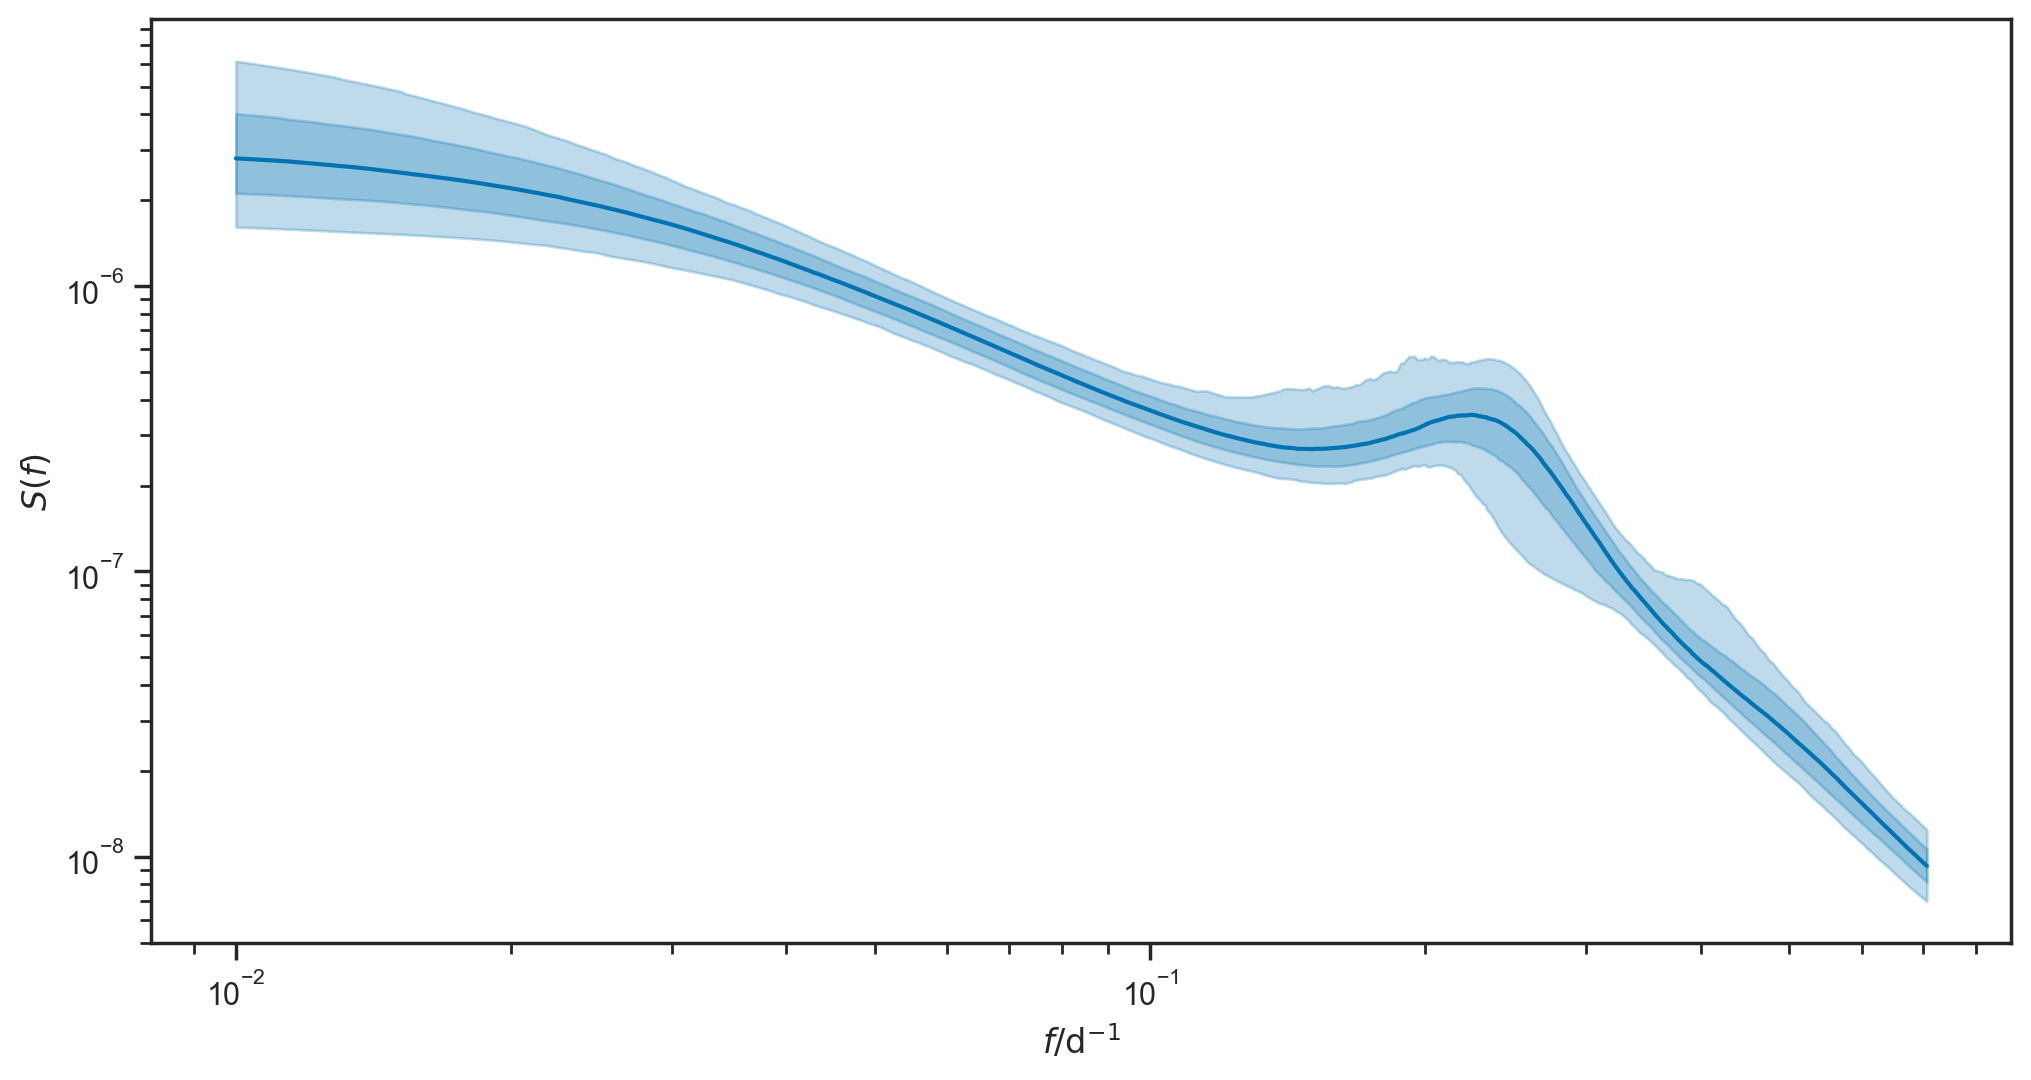

In [37]:
# Get PSD samples (using your method)
n_total = len(results['period'])  
n_samples = 1000  
selected_indices = np.random.choice(n_total, size=n_samples)

psd_samples = []
for i in range(n_samples):
    walker_idx = np.random.randint(0, nwalkers)
    step_idx = np.random.randint(0, nsteps)
    
    param_dict = {}
    for name, values in results.items():
        # idk why these are not in the graph...
        if name=='f0' or name=='Q0' or name=='Q1' or name=='mus' or name=='log_period' or name=='sigma_scaled' or name=='log_scale_factors_scaled' or name=='scale_factors': continue
        
        if values.ndim == 2:  # (nwalkers, nsteps)
            param_dict[name] = values[walker_idx, step_idx]  
        elif values.ndim == 3:  # (nwalkers, nsteps, nquarters)
            param_dict[name] = values[walker_idx, step_idx, :] 
        
    psd = model.psd.eval(param_dict)
    psd_samples.append(psd)

psd_samples = np.array(psd_samples)

psd_median = np.median(psd_samples, axis=0)
psd_16 = np.percentile(psd_samples, 16, axis=0)
psd_84 = np.percentile(psd_samples, 84, axis=0)
psd_025 = np.percentile(psd_samples, 2.5, axis=0)
psd_975 = np.percentile(psd_samples, 97.5, axis=0)

plt.figure(figsize=(12, 6))
l, = plt.loglog(frequencies, psd_median, label='Posterior')
plt.fill_between(frequencies, psd_84, psd_16, alpha=0.25, color=l.get_color())
plt.fill_between(frequencies, psd_975, psd_025, alpha=0.25, color=l.get_color())

plt.xlabel(r'$f / \mathrm{d}^{-1}$')
plt.ylabel(r'$S(f)$')
plt.show()